#Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

#Derin öğrenme modeli eğitmek için temel kütüphaneler

import tensorflow as tf
from tensorflow.keras import layers,datasets,metrics
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization,Input,Activation
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping

#Eğitimde tekrarlanabilirlik sağlamak adına rastgelelik değerini sabitliyoruz

random.seed(32)
np.random.seed(32)
tf.random.set_seed(32)


#Dataset

In [2]:
# Model eğitimi ve doğrulama aşamaları için CIFAR-10 görüntü veri setini yüklüyorum
(X_train,y_train),(X_val,y_val)=datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [3]:
#Elimizdeki train  verilerinin boyutuna bakalım
print("X_train verisinin boyutu = ",X_train.shape)
print("y_train verisiinin boyutu = ",y_train.shape)

X_train verisinin boyutu =  (50000, 32, 32, 3)
y_train verisiinin boyutu =  (50000, 1)


In [4]:
# Modelin performansını test edeceğimiz doğrulama verilerinin boyutuna bakıp doğrulayalım
print("X_val verisinin boyutu = ",X_val.shape)
print("X_val verisinin boyutu = ",y_val.shape)

X_val verisinin boyutu =  (10000, 32, 32, 3)
X_val verisinin boyutu =  (10000, 1)


array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
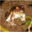

In [5]:
#X_train verimiizin ilk elemanına bir göz atalım
X_train[0]

In [6]:
# Verinin 'Label Encoding' (indeks) formatında olduğunu doğrulamak için yapısını kontrol ediyorum.
y_val

array([[3],
       [8],
       [8],
       ...,
       [5],
       [1],
       [7]], dtype=uint8)

In [7]:
# Veri setinden rastgele örnekleri görselleştirerek veri dağılımını ve etiket eşleşmelerini kontrol ediyorum.
def show_random_examples(images, labels, num_examples=25, figsize=(10, 10)):
    indices = np.random.choice(len(images), num_examples, replace=False)
    plt.figure(figsize=figsize)
    for i, idx in enumerate(indices):
        plt.subplot(5, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[idx], cmap='gray')
        plt.xlabel(labels[idx])
    plt.show()

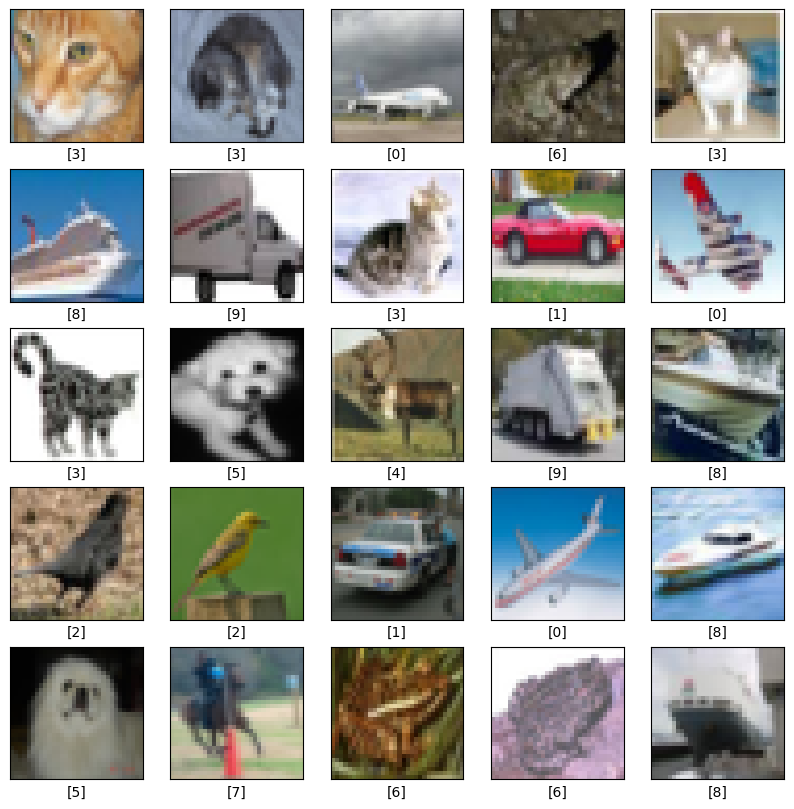

In [8]:
#Üstdeki fonksiyonu çağırıp içinden rastgele görüntüler alııp bakalım
show_random_examples(X_train,y_train)

#Data Preparation

In [9]:
# Piksel değerlerini 0-1 arasına çekerek normalleştiriyorum.
X_train,X_val=X_train/255.0,X_val/255.0

In [10]:
#Bi kontrol edelim
X_train[0:10]

array([[[[0.23137255, 0.24313725, 0.24705882],
         [0.16862745, 0.18039216, 0.17647059],
         [0.19607843, 0.18823529, 0.16862745],
         ...,
         [0.61960784, 0.51764706, 0.42352941],
         [0.59607843, 0.49019608, 0.4       ],
         [0.58039216, 0.48627451, 0.40392157]],

        [[0.0627451 , 0.07843137, 0.07843137],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509804, 0.21568627],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117647, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215686, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941176, 0.19607843],
         [0.47058824, 0.32941176, 0.19607843],
         [0.42745098, 0.28627451, 0.16470588]],

        ...,

        [[0.81568627, 0.66666667, 0.37647059],
         [0.78823529, 0.6       , 0.13333333]

In [11]:
#Elimizdeki verileri tensor formatına çevirmek için bir fonksiyon yazdım
def tensor_veri_hazirlama(X_train,X_val,y_train,y_val,batch_size=None):
  if batch_size is None:
    batch_size=len(X_train)

  train_dataset=tf.data.Dataset.from_tensor_slices((X_train,y_train))
  train_dataset=train_dataset.shuffle(buffer_size=len(X_train)).batch(batch_size)
  val_dataset=tf.data.Dataset.from_tensor_slices((X_val,y_val))
  val_dataset=val_dataset.batch(batch_size)

  return train_dataset,val_dataset

In [12]:
#Şimdi bu fonksiyonu çağırıp elimizdeki verileri dönüştürelim
train_ds,val_ds=tensor_veri_hazirlama(X_train,X_val,y_train,y_val,batch_size=32)

#Create & Compile Model

In [13]:

model=Sequential([
    Input(shape = (32,32,3)),#32 ye 32 lik 3 kanallı bir resim var demek istiyor

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),

    layers.Flatten(),

    layers.Dense(256,activation='relu'),
    layers.Dense(10,activation='softmax')


])

In [14]:
# Modelin eğitim başarısını ölçmek için doğruluk ve ayırdedicilik (AUC) metriklerini tanımlıyorum.
metrics=[
    metrics.SparseCategoricalAccuracy(name='sparse_categorical_accuracy'),
    metrics.AUC(name='auc',multi_label=True)
]

In [15]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=metrics)

In [16]:
# Model eğitimini optimize etmek ve en iyi ağırlıkları korumak için callback yapılarını tanımlıyorum.
early_stopping=EarlyStopping(monitor='val_loss',
                             patience=20,
                             verbose=1)

model_checkpoint=ModelCheckpoint(filepath='cifar10_model.keras',
                                 monitor='val_loss',
                                 save_best_only=True,
                                 save_weights_only=False,
                                 verbose=1)

In [17]:
# Eğitim sürecini başlatıyorum; model hazırlanan veri setleri ve callback kuralları ile 100 epoch boyunca eğitilecek.
history = model.fit(train_ds,
                    epochs=100,
                    validation_data=val_ds,
                    callbacks=[early_stopping, model_checkpoint])


Epoch 1/100
1562/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - auc: 0.5385 - loss: 1.7324 - sparse_categorical_accuracy: 0.3544
Epoch 1: val_loss improved from None to 1.26250, saving model to cifar10_model.keras

Epoch 1: finished saving model to cifar10_model.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 52ms/step - auc: 0.5350 - loss: 1.4914 - sparse_categorical_accuracy: 0.4538 - val_auc: 0.5306 - val_loss: 1.2625 - val_sparse_categorical_accuracy: 0.5494
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - auc: 0.5267 - loss: 1.1465 - sparse_categorical_accuracy: 0.5928
Epoch 2: val_loss improved from 1.26250 to 1.01279, saving model to cifar10_model.keras

Epoch 2: finished saving model to cifar10_model.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 54ms/step - auc: 0.5273 - loss: 1.1048 - sparse_categorical_accuracy: 0.6087 - val_auc: 0.5374 - val_loss: 1.0128 - val_sparse_categorical_accuracy: 0.6402
Epoch 3/100
1562/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - auc: 0.5262 - loss: 0.9626 - sp

In [18]:
# Eğitim geçmişini (loss ve metrikler) grafikleştirerek modelin performansını ve öğrenme sürecini analiz ediyorum.
def plot_training_history(history, train_loss='loss', train_metric='accuracy', val_loss='val_loss', val_metric='val_accuracy'):

    #Loss
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_loss], label='Training Loss')
    plt.plot(history.history[val_loss], label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Metrics
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_metric], label=f"Training: {train_metric}")
    plt.plot(history.history[val_metric], label=f"Validation: {val_metric}")
    plt.title(f'Training and Validation {train_metric} Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel(f'train_metric')
    plt.legend()
    plt.show()

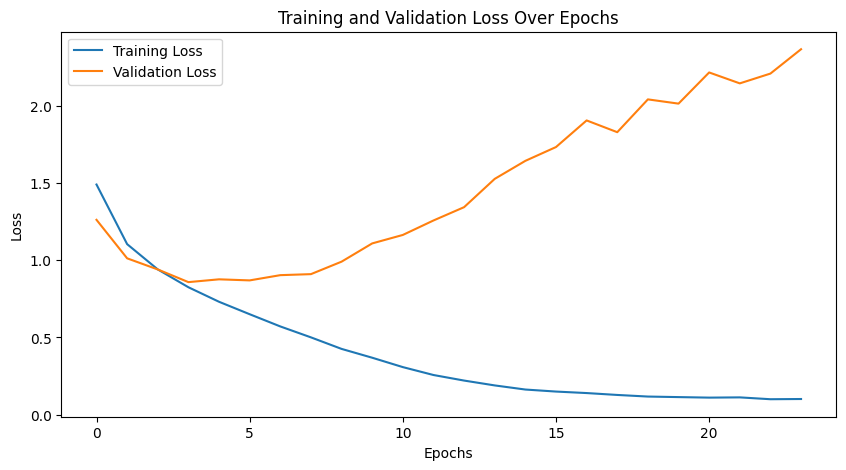

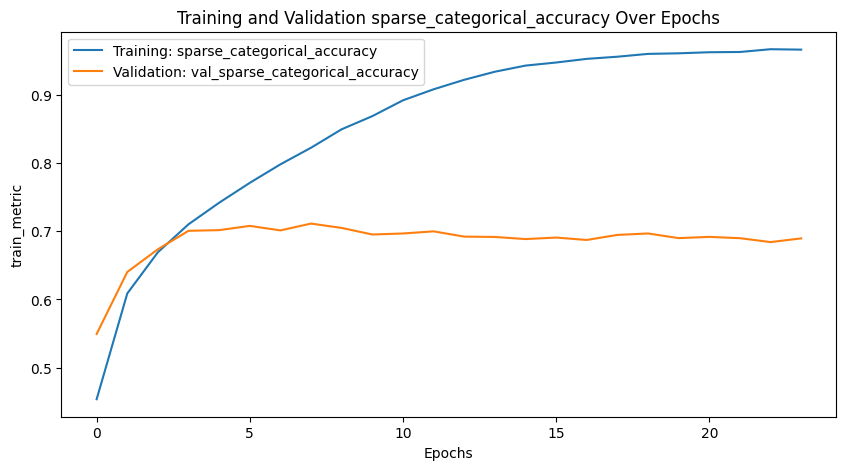

In [19]:
plot_training_history(history, train_loss='loss', train_metric='sparse_categorical_accuracy', val_loss='val_loss', val_metric='val_sparse_categorical_accuracy')

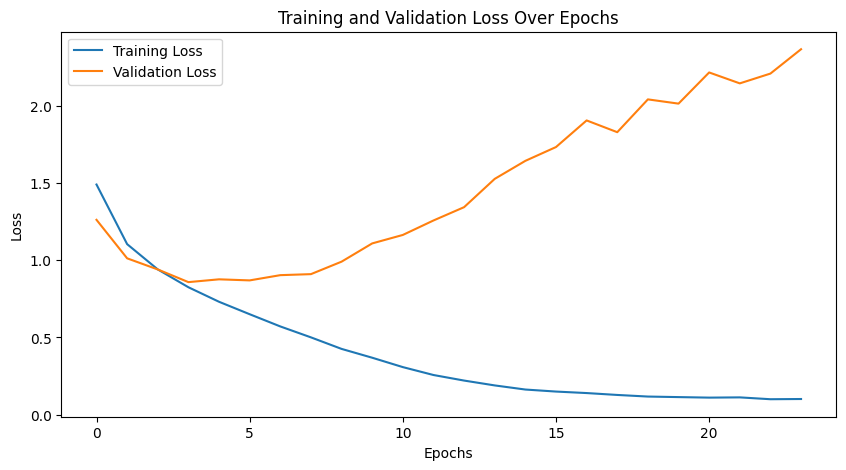

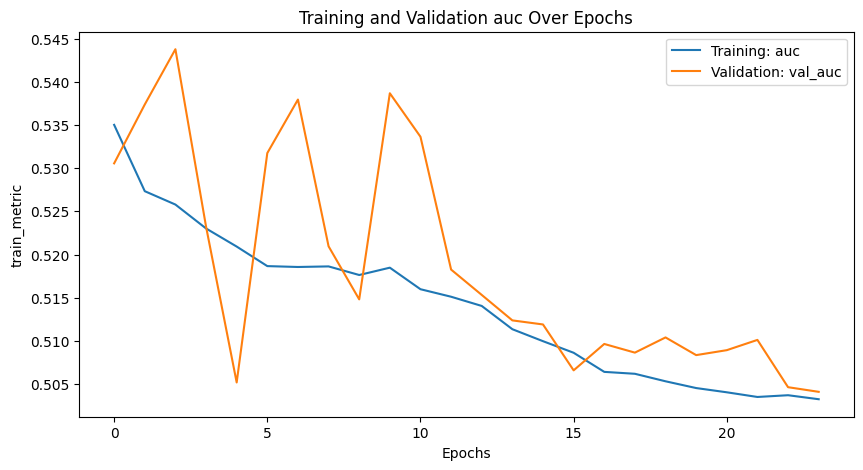

In [20]:
plot_training_history(history, train_loss='loss', train_metric='auc', val_loss='val_loss', val_metric='val_auc')

In [21]:
# Eğitimi tamamlanan modelin, doğrulama veri kümesi üzerindeki performansını (Loss, Accuracy, AUC) değerlendiriyorum.

val_loss, sparse_categorical_accuracy, auc = model.evaluate(val_ds, verbose=0)
print(f"Loss: {val_loss}")
print(f"Accuracy: {sparse_categorical_accuracy}")
print(f"AUC: {auc}")

Loss: 2.368875503540039
Accuracy: 0.6894000172615051
AUC: 0.5040841102600098
